Dataset import

/images -> raw images of the dataset

/fixations -> binary map. 1 where users pointed at saliency point

/maps -> continous version of the fixation, values from 0 to 255, interpolated from fixations

Note: the same 12 long id identifies a sample across images, fixations and maps

!pip install kaggle
!kaggle datasets download -d roshan401/salicon \
  -p ./datasets/salicon --unzip

./datasets/salicon 3 0
./datasets/salicon/fixations 3 0
./datasets/salicon/fixations/test 0 5000
./datasets/salicon/fixations/train 0 10000
./datasets/salicon/fixations/val 0 5000
./datasets/salicon/images 1 0
./datasets/salicon/images/images 3 0
./datasets/salicon/images/images/test 0 5000
./datasets/salicon/images/images/train 0 10000
./datasets/salicon/images/images/val 0 5000
./datasets/salicon/maps 2 0
./datasets/salicon/maps/train 0 10000
./datasets/salicon/maps/val 0 5000
Image size : (640, 480)
Map size : (640, 480)
RGB
L
uint8 0 255


Text(0.5, 1.0, 'Saliency')

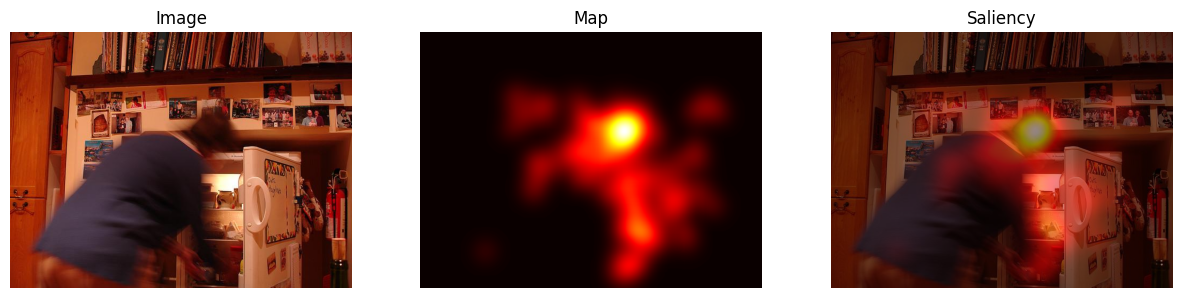

In [1]:
import os
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import random
from matplotlib import image
from torch.utils.data import Dataset, DataLoader
from torchvision.transforms import Compose, Resize, ToTensor, Normalize
from torch.utils.data import DataLoader
import torchvision.models as models
import torch
from torch import nn
from torchinfo import summary
from torch.optim import Adam
import torch.nn.functional as F
from torchvision.transforms import functional as TF
import math

seed = np.random.seed(42)
random.seed(42)

root = './datasets/salicon'
os.walk(root)

for dirpath, dirnames, filenames in os.walk(root):
    print(dirpath, len(dirnames), len(filenames))

TRAIN_DIR = Path(root) / "images/images"
FIX_DIR = Path(root) / "fixations"
MAP_DIR = Path(root) / "maps"

img1 = Image.open(root + '/images/images/train/COCO_train2014_000000096723.jpg')
img2 = Image.open(root + '/maps/train/COCO_train2014_000000096723.png')

print(f"Image size : {img1.size}")
print(f"Map size : {img2.size}")
print(img1.mode)
print(img2.mode)

c = np.array(img2)
print(c.dtype, c.min(), c.max())

fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(img1); axes[0].axis("Off"); axes[0].set_title("Image")

axes[1].imshow(img2, cmap="hot"); axes[1].axis("Off"); axes[1].set_title("Map")

axes[2].imshow(img1); axes[2].imshow(img2, cmap="hot", alpha=0.5); axes[2].axis("Off"); axes[2].set_title("Saliency")


In [64]:
#Prepare training data paths
image_paths_train = []
map_paths_train = []
stem_dict = {}

for f in os.listdir(MAP_DIR / 'train'):
  stem = Path(f).stem
  stem_dict[stem] = f

for f in os.listdir(TRAIN_DIR / 'train'):
  stem = Path(f).stem
  if stem in stem_dict:
    image_paths_train.append(TRAIN_DIR / 'train'/ f)
    map_paths_train.append(MAP_DIR /'train'/ stem_dict[stem])

print(f"Train size: {len(image_paths_train)}")
print(f"Train size: {len(map_paths_train)}")

#Prepare val/test
image_paths_val_full = []
map_paths_val_full = []
stem_dict = {}

for f in os.listdir(MAP_DIR / 'val'):
  stem = Path(f).stem
  stem_dict[stem] = f

for f in os.listdir(TRAIN_DIR / 'val'):
  stem = Path(f).stem
  if stem in stem_dict:
    image_paths_val_full.append(TRAIN_DIR / 'val'/ f)
    map_paths_val_full.append(MAP_DIR / 'val'/ stem_dict[stem])

idx = list(range(len(image_paths_val_full)))
random.shuffle(idx)

val_idx, test_idx = idx[:3500], idx[3500:]

image_paths_val = [image_paths_val_full[i] for i in val_idx]
image_paths_test = [image_paths_val_full[i] for i in test_idx]
map_paths_val = [map_paths_val_full[i] for i in val_idx]
map_paths_test = [map_paths_val_full[i] for i in test_idx]

print(f"Val size: {len(image_paths_val)}")
print(f"Test size: {len(image_paths_test)}")

Train size: 10000
Train size: 10000
Val size: 3500
Test size: 1500


In [3]:
class ImageDataset(Dataset):

  def __init__(self, image_paths, map_paths, image_size=(256, 256), train=False):

    self.train = train
    
    if len(image_paths) != len(map_paths):
      raise ValueError("Number of images and maps must be the same")

    self.image_paths = image_paths
    self.map_paths = map_paths
    self.image_size = image_size

    self.image_transform = Compose([
        Resize(self.image_size),
        ToTensor(),
        Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])

    self.map_transform = Compose([
        Resize(self.image_size),
        ToTensor()
    ])

  def __len__(self):
    return len(self.image_paths)

  def __getitem__(self, index):
    image_path = self.image_paths[index]
    map_path = self.map_paths[index]

    image = Image.open(image_path).convert("RGB")
    sal = Image.open(map_path).convert("L")

    if self.train:
        
        r = random.random()       
        if r < 0.5:
            image = TF.hflip(image)
            sal = TF.hflip(sal)

        r = random.random()
        if r < 0.3:
            angle = random.uniform(-10, 10)
            image = TF.rotate(image, angle, interpolation=TF.InterpolationMode.BILINEAR)
            sal = TF.rotate(sal, angle, interpolation=TF.InterpolationMode.BILINEAR)
            
        r = random.random()   
        if r < 0.5:
            image = TF.adjust_brightness(image, random.uniform(0.8, 1.2))
            image = TF.adjust_contrast(image,   random.uniform(0.8, 1.2))
            image = TF.adjust_saturation(image, random.uniform(0.8, 1.2))
        
    return(self.image_transform(image), self.map_transform(sal))


ATTENZIONE: IN LOCALE SU GPU METTI pin_memory = True


In [4]:
train_ds = ImageDataset(image_paths_train, map_paths_train, train=True)
val_ds = ImageDataset(image_paths_val, map_paths_val, train=False)
test_ds = ImageDataset(image_paths_test, map_paths_test, train=False)

train_loader = DataLoader(train_ds, batch_size=16, shuffle=True,  num_workers=8, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=16, shuffle=False, num_workers=8, pin_memory=True, drop_last=True)
test_loader  = DataLoader(test_ds,  batch_size=16, shuffle=False, num_workers=8, pin_memory=True, drop_last=True)

#test:
imgs, sals = next(iter(train_loader))
print(imgs.shape, imgs.dtype)
print(sals.shape, sals.dtype)
print(imgs.min().item(), imgs.max().item())  # dopo Normalize, NON in [0,1]
print(sals.min().item(), sals.max().item())  # in [0,1]

torch.Size([16, 3, 256, 256]) torch.float32
torch.Size([16, 1, 256, 256]) torch.float32
-2.1179039478302 2.640000104904175
0.0 1.0


In [5]:
backbone = models.resnet18()

for name, child in backbone.named_children():
    print(name)

conv1
bn1
relu
maxpool
layer1
layer2
layer3
layer4
avgpool
fc


In [6]:
class encoder(nn.Module):

  def __init__(self):
    super().__init__()

    backbone = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
    self.stem = nn.Sequential(
        backbone.conv1,
        backbone.bn1,
        backbone.relu,
        backbone.maxpool
    )
    self.layer1 = backbone.layer1
    self.layer2 = backbone.layer2
    self.layer3 = backbone.layer3
    self.layer4 = backbone.layer4

    #ignore last 2 layers of resnet

  def forward(self, x):
    x = self.stem(x)
    c1 = self.layer1(x)
    c2 = self.layer2(c1)
    c3 = self.layer3(c2)
    c4 = self.layer4(c3)
    return c1, c2, c3, c4

In [7]:
class decoder(nn.Module):

  def __init__(self):

    super().__init__()

    self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False)
    self.dropout = nn.Dropout2d(0.2)
    self.conv1 = nn.Conv2d(in_channels=768, out_channels=256, kernel_size=3, stride=1, padding=1)
    self.bn1 = nn.BatchNorm2d(256)

    self.conv2 = nn.Conv2d(in_channels=384, out_channels=128, kernel_size=3, stride=1, padding=1)
    self.bn2 = nn.BatchNorm2d(128)

    self.conv3 = nn.Conv2d(in_channels=192, out_channels=64, kernel_size=3, stride=1, padding=1)
    self.bn3 = nn.BatchNorm2d(64)

    self.conv4 = nn.Conv2d(in_channels=64, out_channels=32, kernel_size=3, stride=1, padding=1)
    self.bn4 = nn.BatchNorm2d(32)

    self.conv5 = nn.Conv2d(in_channels=32, out_channels=1, kernel_size=3, stride=1, padding=1)

  def forward(self, c1, c2, c3, c4):

    x = self.up(c4)
    x = torch.cat([x, c3], dim=1)
    x = self.conv1(x)
    x = self.bn1(x)
    x = self.dropout(x)
    x = torch.relu(x)

    x = self.up(x)
    x = torch.cat([x, c2], dim=1)
    x = self.conv2(x)
    x = self.bn2(x)
    x = self.dropout(x)
    x = torch.relu(x)

    x = self.up(x)
    x = torch.cat([x, c1], dim=1)
    x = self.conv3(x)
    x = self.bn3(x)
    x = self.dropout(x)
    x = torch.relu(x)

    x = self.up(x)
    x = self.conv4(x)
    x = self.bn4(x)
    x = self.dropout(x)
    x = torch.relu(x)

    x = self.up(x)
    x = self.conv5(x)

    return x

#sanity check
dummy = encoder()
z = torch.zeros((2, 3, 256, 256))
c1, c2, c3, c4 = dummy.forward(z)
print(c1.shape, c2.shape, c3.shape, c4.shape)
f = decoder()
f.forward(c1, c2, c3, c4)


torch.Size([2, 64, 64, 64]) torch.Size([2, 128, 32, 32]) torch.Size([2, 256, 16, 16]) torch.Size([2, 512, 8, 8])


tensor([[[[ 0.0808, -0.1413, -0.2057,  ...,  0.3369,  0.4433,  0.2699],
          [ 0.1968,  0.0223, -0.1203,  ...,  0.2238,  0.3647,  0.2271],
          [ 0.0991, -0.0539, -0.2351,  ...,  0.2130,  0.3693,  0.2509],
          ...,
          [-0.5994, -0.2105,  0.1713,  ..., -0.1609, -0.0020,  0.0094],
          [-0.3454,  0.0152,  0.3081,  ..., -0.2680, -0.0951, -0.1473],
          [ 0.0373,  0.2459,  0.3417,  ..., -0.2115, -0.1094, -0.1587]]],


        [[[ 0.0779, -0.1240, -0.2300,  ...,  0.0484,  0.1237,  0.0060],
          [ 0.0462, -0.1712, -0.2194,  ...,  0.0605,  0.1229, -0.0480],
          [ 0.1361,  0.0313, -0.0272,  ..., -0.1867, -0.0901, -0.2085],
          ...,
          [ 0.0524,  0.3494,  0.4532,  ..., -0.2376, -0.0144, -0.0154],
          [ 0.1169,  0.4835,  0.5360,  ..., -0.3534, -0.2065, -0.1860],
          [ 0.1491,  0.3355,  0.3316,  ..., -0.0720, -0.1194, -0.2036]]]],
       grad_fn=<ConvolutionBackward0>)

In [8]:
class SaliencyKLLoss(nn.Module):
    def __init__(self, eps=1e-8):
        super().__init__()
        self.eps = eps

    def forward(self, pred_logits, target):
        B = pred_logits.size(0)
        pred = pred_logits.view(B, -1)
        targ = target.view(B, -1)

        log_pred = F.log_softmax(pred, dim=1)
        targ = targ / (targ.sum(dim=1, keepdim=True) + self.eps)

        return F.kl_div(log_pred, targ, reduction='batchmean')

image_encoder = encoder()
image_decoder = decoder()

loss_fn = SaliencyKLLoss()

params_to_optimize = [
    {'params': image_encoder.parameters(), 'lr': 1e-5},
    {'params': image_decoder.parameters(), 'lr': 1e-4},
]
optim = torch.optim.Adam(params_to_optimize, weight_decay=1e-5)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optim, mode='min', factor=0.5, patience=3, min_lr=1e-7)

device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(f'Selected device: {device}')

image_encoder.to(device)
image_decoder.to(device)

Selected device: cuda


decoder(
  (up): Upsample(scale_factor=2.0, mode='bilinear')
  (dropout): Dropout2d(p=0.2, inplace=False)
  (conv1): Conv2d(768, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(384, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv3): Conv2d(192, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv4): Conv2d(64, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv5): Conv2d(32, 1, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
)

In [9]:
# Training function
def train_epoch(encoder, decoder, device, dataloader, loss_fn, optimizer):
    encoder.train()
    decoder.train()
    losses = []
    for image_batch, image_map_batch in dataloader:
        
        image_batch = image_batch.to(device)
        
        image_map_batch = image_map_batch.to(device)
        
        c1, c2, c3, c4 = encoder(image_batch)

        decoded_data = decoder(c1, c2, c3, c4)

        loss = loss_fn(decoded_data, image_map_batch)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        losses.append(loss.detach().cpu().numpy())
    losses = np.mean(losses)
    return losses

In [10]:
def test_epoch(encoder, decoder, device, dataloader, loss_fn):
    encoder.eval()
    decoder.eval()
    val_losses = []
    
    with torch.no_grad():
        for image_batch, image_map_batch in dataloader:
            image_batch = image_batch.to(device)
            image_map_batch = image_map_batch.to(device)
            
            c1, c2, c3, c4 = encoder(image_batch)
            decoded_data = decoder(c1, c2, c3, c4)

            loss = loss_fn(decoded_data, image_map_batch)
            val_losses.append(loss.item())

    return np.mean(val_losses)

EPOCH 1/50
TRAIN - EPOCH 1/50 - loss: 0.3665151000022888
VALIDATION - EPOCH 1/50 - loss: 0.26783587510159257



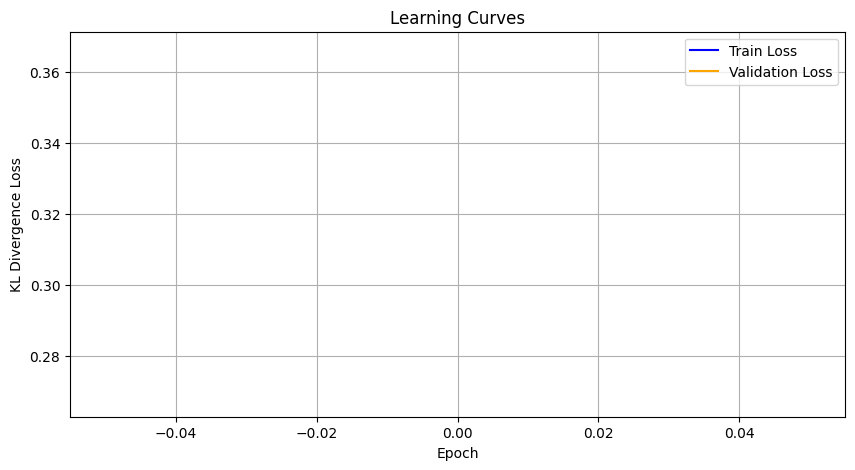

EPOCH 2/50
TRAIN - EPOCH 2/50 - loss: 0.2881588041782379
VALIDATION - EPOCH 2/50 - loss: 0.25105033179215336



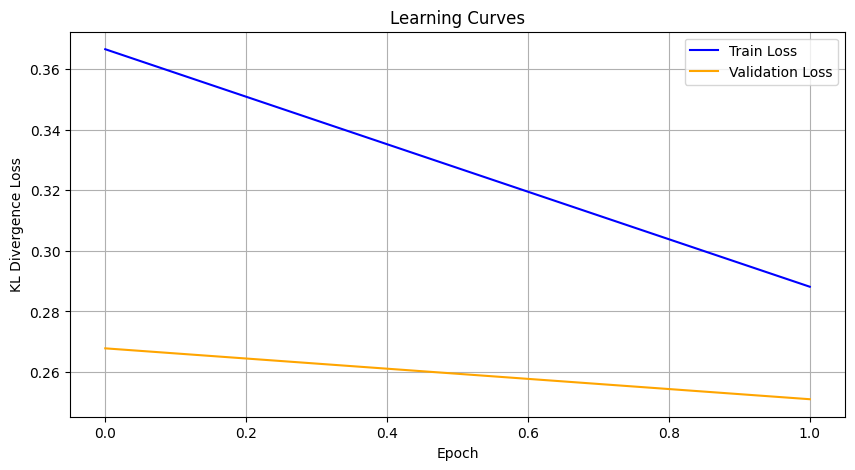

EPOCH 3/50
TRAIN - EPOCH 3/50 - loss: 0.26747632026672363
VALIDATION - EPOCH 3/50 - loss: 0.24259059404561278



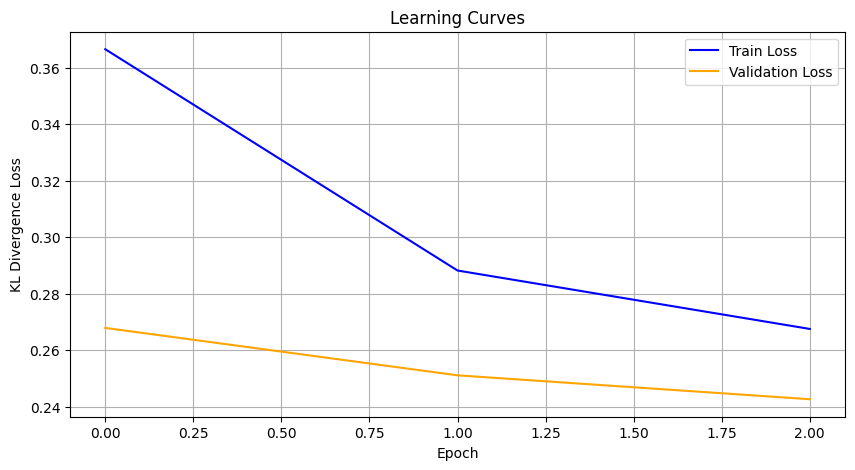

EPOCH 4/50
TRAIN - EPOCH 4/50 - loss: 0.25524693727493286
VALIDATION - EPOCH 4/50 - loss: 0.2411885870569343



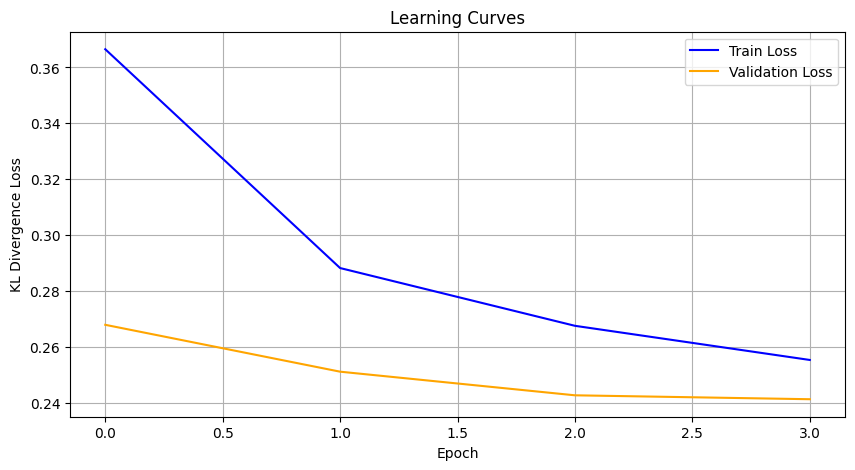

EPOCH 5/50


In [ ]:
num_epochs = 50
train_loss_history = []
val_loss_history = []
bad, patience = 0, 7
best_val_error = float('inf')

for epoch in range(num_epochs):
    print('EPOCH %d/%d' % (epoch + 1, num_epochs))
    ### Training (use the training function)
    train_loss = train_epoch(
        encoder=image_encoder,
        decoder=image_decoder,
        device=device,
        dataloader=train_loader,
        loss_fn=loss_fn,
        optimizer=optim)
    print(f'TRAIN - EPOCH {epoch+1}/{num_epochs} - loss: {train_loss}')

    ### Validation  (use the testing function)
    val_loss = test_epoch(
        encoder=image_encoder,
        decoder=image_decoder,
        device=device,
        dataloader=val_loader,
        loss_fn=loss_fn)
    
    scheduler.step(val_loss)
    
    # Print Validation curves
    print(f'VALIDATION - EPOCH {epoch+1}/{num_epochs} - loss: {val_loss}\n')
    train_loss_history.append(train_loss)
    val_loss_history.append(val_loss)

    plt.figure(figsize=(10, 5))
    plt.plot(train_loss_history, label='Train Loss', color='blue')
    plt.plot(val_loss_history, label='Validation Loss', color='orange')
    plt.title('Learning Curves')
    plt.xlabel('Epoch')
    plt.ylabel('KL Divergence Loss')
    plt.legend()
    plt.grid(True)
    plt.show()

    if best_val_error > val_loss:
        best_val_error = val_loss
        bad = 0
        torch.save({"encoder" : image_encoder.state_dict(), "decoder" : image_decoder.state_dict()}, 'best.pt')
    else:
        bad += 1
        if bad == patience:
            break
        


In [11]:
def cc_metric(pred, target, eps=1e-8):
    
    B = pred.size(0)
    p = pred.view(B, -1).float()
    t = target.view(B, -1).float()
    
    p = p - p.mean(dim=1, keepdim=True)
    t = t - t.mean(dim=1, keepdim=True)
    
    num = (p * t).sum(dim=1)
    den = torch.sqrt((p * p).sum(dim=1) * (t * t).sum(dim=1) + eps)
    
    return (num / den)  # per-sample, mediato fuori

In [12]:
def sim_metric(pred, ground_truth, eps=1e-8):
    
    pred = pred.float()
    ground_truth = ground_truth.float()
    
    B = pred.size(0)
    pred_flatten = pred.view(B, -1)
    ground_truth_flatten = ground_truth.view(B, -1)
    
    pred_sum = pred_flatten.sum(dim=1, keepdim=True) + eps
    gt_sum = ground_truth_flatten.sum(dim=1, keepdim=True) + eps
    
    pred_normalized = pred_flatten / pred_sum
    ground_normalized = ground_truth_flatten / gt_sum

    minimum = torch.minimum(pred_normalized, ground_normalized)
    sim_per_image = minimum.sum(dim=1) 

    return sim_per_image.mean()

In [13]:
def kl_metric(pred, ground_truth, eps=1e-8):

    pred = pred.float()
    ground_truth = ground_truth.float()
    
    B = pred.size(0)
    pred = pred.view(B, -1)
    targ = ground_truth.view(B, -1)

    log_pred = F.log_softmax(pred, dim=1)
    targ = targ / (targ.sum(dim=1, keepdim=True) + eps)

    return F.kl_div(log_pred, targ, reduction='batchmean')

In [66]:
def nss_metric(pred, ground_truth, eps=1e-8):

    pred = pred.float()
    ground_truth = ground_truth.float()

    B = pred.size(0)
    pred_flatten = pred.view(B, -1)
    ground_truth_flatten = ground_truth.view(B, -1)

    mean = pred_flatten.sum(dim=1, keepdim=True) / pred_flatten.shape[1]
    std = (((pred_flatten ** 2) + (mean ** 2) - (2 * mean * pred_flatten)).sum(dim=1, keepdim=True) / pred_flatten.shape[1]) ** 0.5

    pred_flatten = (pred_flatten - mean) / (std + eps)

    ground_truth_flatten = (ground_truth_flatten > 0.9).float()

    pred_flatten *= ground_truth_flatten

    return (pred_flatten.sum(dim=1) / (ground_truth_flatten.sum(dim=1) + eps)).mean()

In [67]:
#Metrics setup: load saved best model

model = torch.load('best.pt', map_location=device,weights_only=False)
image_encoder.load_state_dict(model['encoder'])
image_decoder.load_state_dict(model['decoder'])
image_encoder.eval()
image_decoder.eval()

sim_metrics = []
cc_metrics = []
nss_metrics = []
kl_metrics = []

c = 0
#Metrics over Validation:
with torch.no_grad():
    
    for image_batch, image_map_batch in val_loader:
    
            image_batch = image_batch.to(device)
            image_map_batch = image_map_batch.to(device)
            
            c1, c2, c3, c4 = image_encoder(image_batch)
            decoded_data = image_decoder(c1, c2, c3, c4)
            
            flattened_decoded_data = decoded_data.view(B, -1)
            log_decoded_data = F.softmax(flattened_decoded_data, dim=1)
            normalized_decoded_data = log_decoded_data.view_as(decoded_data)
        
            sim_metrics.append(sim_metric(normalized_decoded_data, image_map_batch))
            cc_metrics.append(cc_metric(normalized_decoded_data, image_map_batch))
            nss_metrics.append(nss_metric(normalized_decoded_data, image_map_batch))
            kl_metrics.append(kl_metric(decoded_data, image_map_batch))

print(f'VALIDATION METRICS: \nSIM: {torch.stack(sim_metrics).mean()}\n CC: {torch.stack(cc_metrics).mean()}\n NSS: {torch.stack(nss_metrics).mean()}\n KL: {torch.stack(kl_metrics).mean()}')

#Metrics over test
sim_metrics = []
cc_metrics = []
nss_metrics = []
kl_metrics = []

with torch.no_grad():
    
    for image_batch, image_map_batch in test_loader:
    
            image_batch = image_batch.to(device)
            image_map_batch = image_map_batch.to(device)
            
            c1, c2, c3, c4 = image_encoder(image_batch)
            decoded_data = image_decoder(c1, c2, c3, c4)

            #PER ALESSANDRO: LE NOSTRE FUNZIONI DI METRICHE PRENDONO COME ARGOMENTI I VALORI GIA NORMALIZZATI, PERCIO HO DOVUTO NORMALIZZARLI
            #USANDO QUESTE 3 RIGHE DI CODICE (ECCEZIONE PER KL)
            flattened_decoded_data = decoded_data.view(B, -1)
            log_decoded_data = F.softmax(flattened_decoded_data, dim=1)
            normalized_decoded_data = log_decoded_data.view_as(decoded_data)
        
            sim_metrics.append(sim_metric(normalized_decoded_data, image_map_batch))
            cc_metrics.append(cc_metric(normalized_decoded_data, image_map_batch))
            nss_metrics.append(nss_metric(normalized_decoded_data, image_map_batch))
            kl_metrics.append(kl_metric(decoded_data, image_map_batch))

print(f'TEST METRICS : \nSIM: {torch.stack(sim_metrics).mean()}\n CC: {torch.stack(cc_metrics).mean()}\n NSS: {torch.stack(nss_metrics).mean()}\n KL: {torch.stack(kl_metrics).mean()}')

VALIDATION METRICS: 
SIM: 0.7688717842102051
 CC: 0.878577470779419
 NSS: 4.4469194412231445
 KL: 0.2361583411693573
TEST METRICS : 
SIM: 0.7719218134880066
 CC: 0.8788809776306152
 NSS: 4.449815273284912
 KL: 0.22978579998016357


>>> STEP 1: predizioni vs GT (4 esempi)


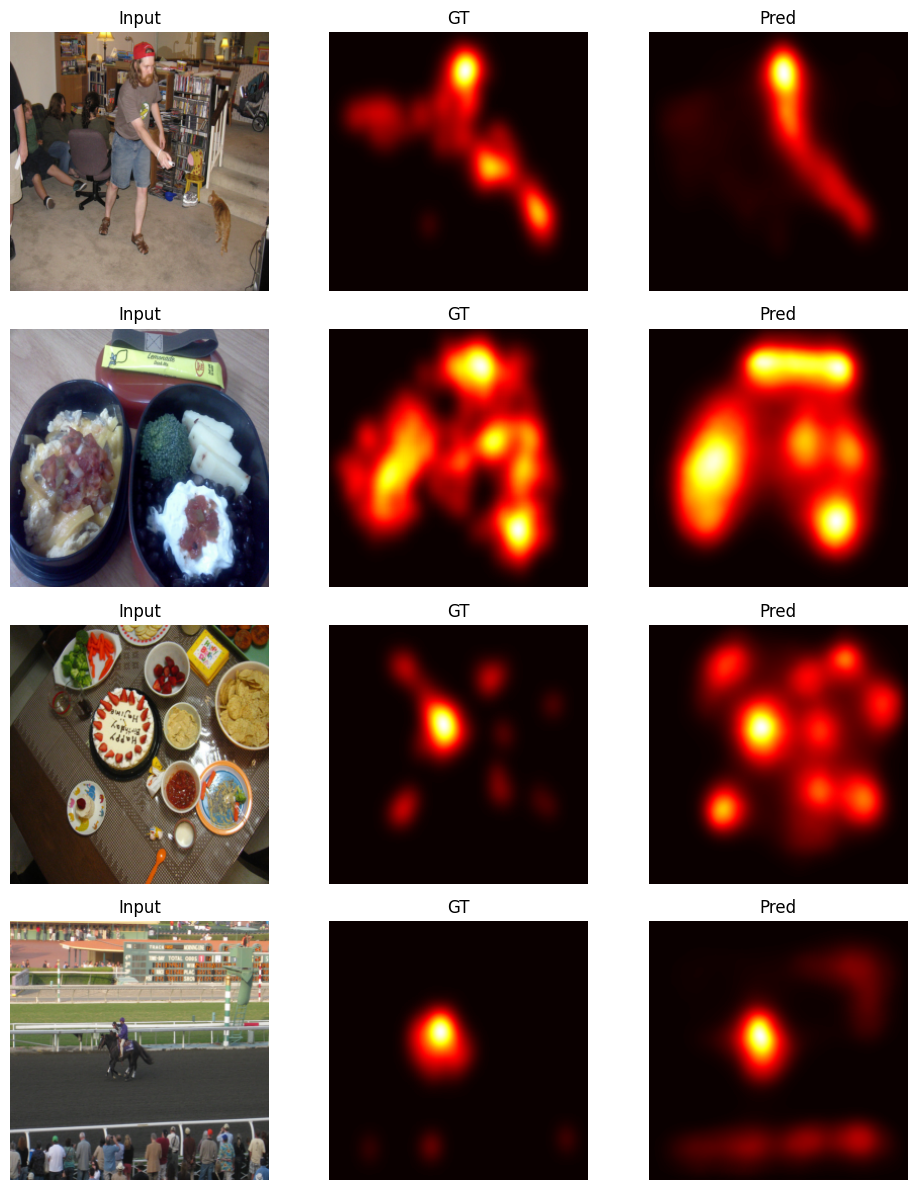


>>> STEP 2+3: metriche su val set completo

  KL  modello       : 0.2362
  KL  center prior  : 0.7919
  -> il modello batte il center prior di +0.5558 (più alto = meglio)

  CC  modello       : 0.8786
  CC  center prior  : 0.5356
  -> il modello batte il center prior di +0.3430 (più alto = meglio)

Interpretazione rapida:
  - se KL_model è MOLTO vicino a KL_center -> il modello ha imparato poco oltre il bias centrale
  - se CC_model > 0.7 sei in territorio decente per ResNet18 baseline
  - se CC_model ~ CC_center (0.45-0.55 tipico per center prior) -> il modello non sta imparando


In [55]:
# ============================================================
# CELLA DIAGNOSTICA TEMPORANEA - buttare dopo l'uso
# ============================================================
# Assicurati che image_encoder, image_decoder, val_loader, device siano definiti.
# Se hai un best.pt salvato, decommenta queste 3 righe per caricarlo:
ckpt = torch.load('best.pt', map_location=device)
image_encoder.load_state_dict(ckpt['encoder'])
image_decoder.load_state_dict(ckpt['decoder'])

import torch
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt

image_encoder.eval()
image_decoder.eval()

# ---------- helper: normalizza pred a [0,1] per visualizzazione e CC ----------
def predict_normalized(imgs):
    """Restituisce mappa in [0,1] (divisa per il max per immagine)."""
    c1, c2, c3, c4 = image_encoder(imgs)
    logits = image_decoder(c1, c2, c3, c4)
    B = logits.size(0)
    prob = F.softmax(logits.view(B, -1), dim=1).view_as(logits)
    pred = prob / (prob.amax(dim=(2, 3), keepdim=True) + 1e-8)
    return pred, logits

# ---------- metrica CC ----------
def cc_metric(pred, target, eps=1e-8):
    B = pred.size(0)
    p = pred.view(B, -1).float()
    t = target.view(B, -1).float()
    p = p - p.mean(dim=1, keepdim=True)
    t = t - t.mean(dim=1, keepdim=True)
    num = (p * t).sum(dim=1)
    den = torch.sqrt((p * p).sum(dim=1) * (t * t).sum(dim=1) + eps)
    return (num / den)  # per-sample, mediato fuori

# ---------- center prior baseline ----------
H = W = 256
yy, xx = torch.meshgrid(torch.arange(H), torch.arange(W), indexing='ij')
center = torch.exp(-((yy - H/2)**2 + (xx - W/2)**2) / (2 * (H/4)**2)).float()
center_dist = (center / center.sum()).to(device)              # distribuzione, somma=1
log_center = torch.log(center_dist + 1e-8).view(1, -1)        # per KL
center_norm = (center / center.max()).to(device)              # in [0,1] per CC

# ---------- STEP 1: visualizza 4 esempi ----------
print(">>> STEP 1: predizioni vs GT (4 esempi)")
with torch.no_grad():
    imgs, sals = next(iter(val_loader))
    imgs = imgs.to(device)
    sals = sals.to(device)
    pred, _ = predict_normalized(imgs)

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std  = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)

n = min(4, imgs.size(0))
fig, ax = plt.subplots(n, 3, figsize=(10, 3 * n))
for i in range(n):
    img_show = (imgs[i].cpu() * std + mean).clamp(0, 1).permute(1, 2, 0)
    ax[i, 0].imshow(img_show); ax[i, 0].set_title("Input"); ax[i, 0].axis('off')
    ax[i, 1].imshow(sals[i, 0].cpu(), cmap='hot'); ax[i, 1].set_title("GT"); ax[i, 1].axis('off')
    ax[i, 2].imshow(pred[i, 0].cpu(), cmap='hot'); ax[i, 2].set_title("Pred"); ax[i, 2].axis('off')
plt.tight_layout(); plt.show()

# ---------- STEP 2 + 3: CC e KL del modello vs center prior, su TUTTO val ----------
print("\n>>> STEP 2+3: metriche su val set completo")

kl_model_all, cc_model_all = [], []
kl_center_all, cc_center_all = [], []

with torch.no_grad():
    for imgs, sals in val_loader:
        imgs = imgs.to(device)
        sals = sals.to(device)
        B = imgs.size(0)

        # --- modello ---
        pred, logits = predict_normalized(imgs)

        # KL come la calcoli in training
        pred_flat = logits.view(B, -1)
        targ_flat = sals.view(B, -1)
        log_pred = F.log_softmax(pred_flat, dim=1)
        targ_norm = targ_flat / (targ_flat.sum(dim=1, keepdim=True) + 1e-8)
        kl_m = F.kl_div(log_pred, targ_norm, reduction='batchmean')
        kl_model_all.append(kl_m.item())

        # CC su mappa normalizzata vs GT normalizzata in [0,1]
        sals_for_cc = sals / (sals.amax(dim=(2, 3), keepdim=True) + 1e-8)
        cc_m = cc_metric(pred, sals_for_cc)
        cc_model_all.append(cc_m.cpu().numpy())

        # --- center prior baseline ---
        log_center_b = log_center.expand(B, -1)
        kl_c = F.kl_div(log_center_b, targ_norm, reduction='batchmean')
        kl_center_all.append(kl_c.item())

        center_pred = center_norm.view(1, 1, H, W).expand(B, 1, H, W)
        cc_c = cc_metric(center_pred, sals_for_cc)
        cc_center_all.append(cc_c.cpu().numpy())

kl_model  = np.mean(kl_model_all)
kl_center = np.mean(kl_center_all)
cc_model  = np.concatenate(cc_model_all).mean()
cc_center = np.concatenate(cc_center_all).mean()

print(f"\n  KL  modello       : {kl_model:.4f}")
print(f"  KL  center prior  : {kl_center:.4f}")
print(f"  -> il modello batte il center prior di {kl_center - kl_model:+.4f} (più alto = meglio)")
print()
print(f"  CC  modello       : {cc_model:.4f}")
print(f"  CC  center prior  : {cc_center:.4f}")
print(f"  -> il modello batte il center prior di {cc_model - cc_center:+.4f} (più alto = meglio)")
print()
print("Interpretazione rapida:")
print("  - se KL_model è MOLTO vicino a KL_center -> il modello ha imparato poco oltre il bias centrale")
print("  - se CC_model > 0.7 sei in territorio decente per ResNet18 baseline")
print("  - se CC_model ~ CC_center (0.45-0.55 tipico per center prior) -> il modello non sta imparando")